In [4]:
!pip install xgboost lightgbm pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")

XGBoost version: 3.2.0
LightGBM version: 4.6.0


In [10]:
from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"File terupload: {filename}")

df = pd.read_csv(filename)

print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print(df.head())

print("TIPE DATA")
print(df.dtypes)

print("\nSTATISTIK DESKRIPTIF")
print(df.describe())

print("\nMISSING VALUES")
print(df.isnull().sum())

Saving CAR DETAILS FROM CAR DEKHO.csv to CAR DETAILS FROM CAR DEKHO (4).csv
File terupload: CAR DETAILS FROM CAR DEKHO (4).csv
Jumlah baris: 4340, Jumlah kolom: 8
                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Hyundai Verna 1.6 SX  2012         600000     100000  Diesel   
3    Datsun RediGO T Option  2017         250000      46000  Petrol   
4     Honda Amaze VX i-DTEC  2014         450000     141000  Diesel   

  seller_type transmission         owner  
0  Individual       Manual   First Owner  
1  Individual       Manual   First Owner  
2  Individual       Manual   First Owner  
3  Individual       Manual   First Owner  
4  Individual       Manual  Second Owner  
TIPE DATA
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      objec

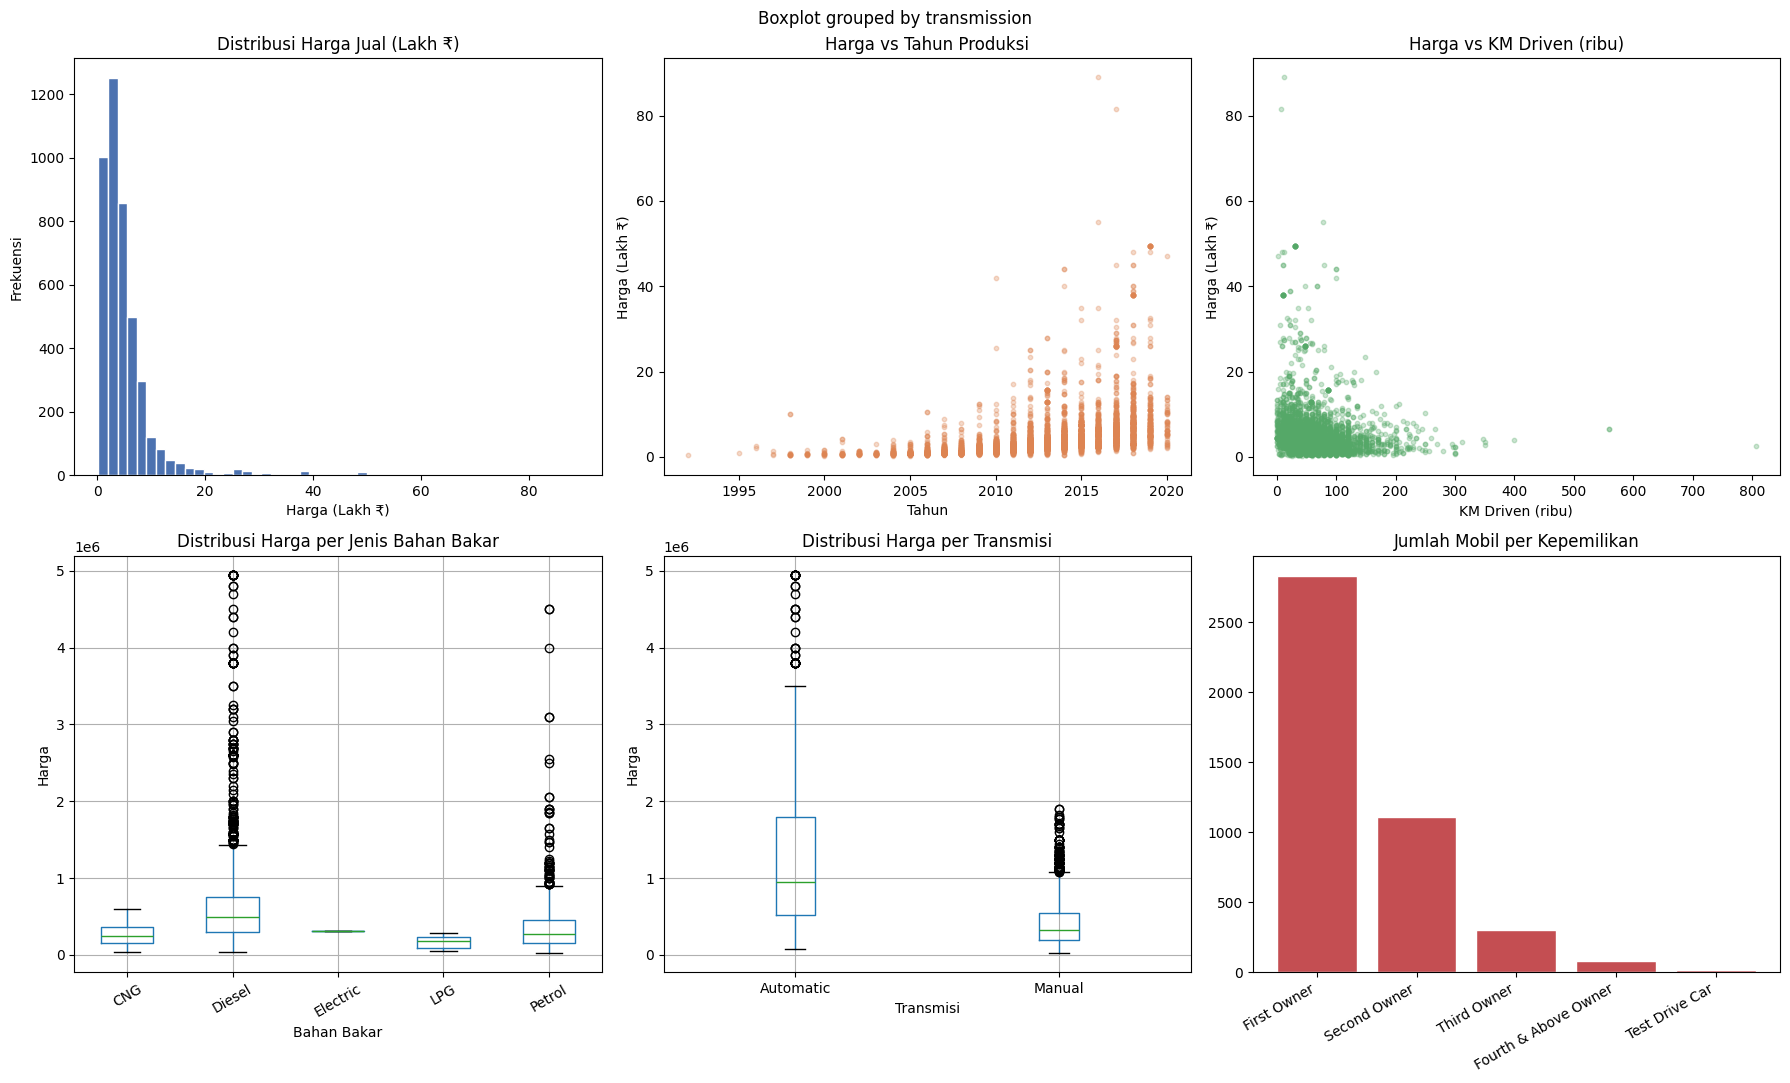

Plot EDA tersimpan sebagai 01_eda.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Car Price Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Distribusi harga
axes[0,0].hist(df['selling_price']/1e5, bins=50, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Distribusi Harga Jual (Lakh ₹)')
axes[0,0].set_xlabel('Harga (Lakh ₹)')
axes[0,0].set_ylabel('Frekuensi')

# 2. Harga vs Tahun
axes[0,1].scatter(df['year'], df['selling_price']/1e5, alpha=0.3, s=10, color='#DD8452')
axes[0,1].set_title('Harga vs Tahun Produksi')
axes[0,1].set_xlabel('Tahun')
axes[0,1].set_ylabel('Harga (Lakh ₹)')

# 3. Harga vs KM
axes[0,2].scatter(df['km_driven']/1000, df['selling_price']/1e5,
                  alpha=0.3, s=10, color='#55A868')
axes[0,2].set_title('Harga vs KM Driven (ribu)')
axes[0,2].set_xlabel('KM Driven (ribu)')
axes[0,2].set_ylabel('Harga (Lakh ₹)')

# 4. Boxplot per Fuel
fuel_order = df.groupby('fuel')['selling_price'].median().sort_values(ascending=False).index
df_filtered = df[df['selling_price']/1e5 < 50]
df_filtered.boxplot(column='selling_price', by='fuel', ax=axes[1,0])
axes[1,0].set_title('Distribusi Harga per Jenis Bahan Bakar')
axes[1,0].set_xlabel('Bahan Bakar')
axes[1,0].set_ylabel('Harga')
plt.sca(axes[1,0])
plt.xticks(rotation=30)

# 5. Boxplot per Transmisi
df_filtered.boxplot(column='selling_price', by='transmission', ax=axes[1,1])
axes[1,1].set_title('Distribusi Harga per Transmisi')
axes[1,1].set_xlabel('Transmisi')
axes[1,1].set_ylabel('Harga')

# 6. Count per Owner
owner_counts = df['owner'].value_counts()
axes[1,2].bar(range(len(owner_counts)), owner_counts.values, color='#C44E52', edgecolor='white')
axes[1,2].set_title('Jumlah Mobil per Kepemilikan')
axes[1,2].set_xticks(range(len(owner_counts)))
axes[1,2].set_xticklabels(owner_counts.index, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot EDA tersimpan sebagai 01_eda.png")

In [12]:
data = df.copy()

# Ekstrak brand dari nama mobil (kata pertama)
data['brand'] = data['name'].str.split().str[0]
print(f"Jumlah brand unik: {data['brand'].nunique()}")
print(data['brand'].value_counts().head(10))

# Hapus outlier 1% - 99% pada harga
Q1 = data['selling_price'].quantile(0.01)
Q3 = data['selling_price'].quantile(0.99)
before = len(data)
data = data[(data['selling_price'] >= Q1) & (data['selling_price'] <= Q3)]
after = len(data)
print(f"\nBaris dihapus karena outlier: {before - after}")
print(f"Baris tersisa: {after}")

# Feature engineering
data['car_age'] = 2024 - data['year']
data['log_km']  = np.log1p(data['km_driven'])

# Label Encoding kolom kategorik
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col + '_enc'] = le.fit_transform(data[col].astype(str))
    le_dict[col] = le
    print(f"Encoded {col}: {list(le.classes_)}")

# Pilih fitur final
feature_cols = ['year', 'km_driven', 'car_age', 'log_km',
                'fuel_enc', 'seller_type_enc', 'transmission_enc',
                'owner_enc', 'brand_enc']

X = data[feature_cols]
y = data['selling_price']

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")


Jumlah brand unik: 29
brand
Maruti        1280
Hyundai        821
Mahindra       365
Tata           361
Honda          252
Ford           238
Toyota         206
Chevrolet      188
Renault        146
Volkswagen     107
Name: count, dtype: int64

Baris dihapus karena outlier: 85
Baris tersisa: 4255
Encoded fuel: ['CNG', 'Diesel', 'Electric', 'LPG', 'Petrol']
Encoded seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
Encoded transmission: ['Automatic', 'Manual']
Encoded owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner']
Encoded brand: ['Ambassador', 'Audi', 'BMW', 'Chevrolet', 'Daewoo', 'Datsun', 'Fiat', 'Force', 'Ford', 'Honda', 'Hyundai', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land', 'MG', 'Mahindra', 'Maruti', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'OpelCorsa', 'Renault', 'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo']

Shape X: (4255, 9)
Shape y: (4255,)

Train: 3404 baris
Test : 851 baris


Best iteration XGBoost: 421
Best RMSE XGBoost (test): 175,579


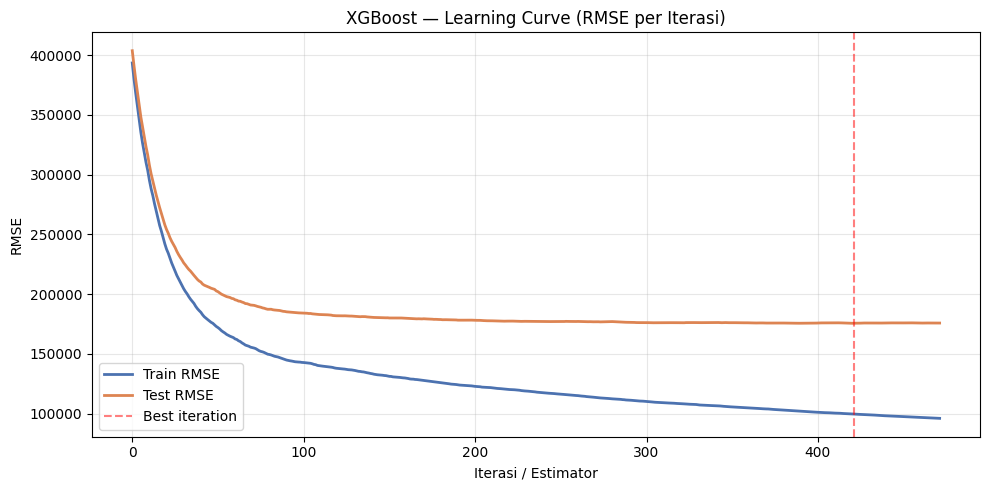

Learning curve XGBoost tersimpan


In [13]:
from xgboost import callback

eval_results_xgb = {}

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# Ambil hasil evaluasi per iterasi
results = xgb_model.evals_result()
train_rmse_xgb = results['validation_0']['rmse']
test_rmse_xgb  = results['validation_1']['rmse']

print(f"Best iteration XGBoost: {xgb_model.best_iteration}")
print(f"Best RMSE XGBoost (test): {min(test_rmse_xgb):,.0f}")

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(train_rmse_xgb, label='Train RMSE', color='#4C72B0', linewidth=2)
plt.plot(test_rmse_xgb, label='Test RMSE', color='#DD8452', linewidth=2)
plt.axvline(x=xgb_model.best_iteration, color='red', linestyle='--', alpha=0.5, label='Best iteration')
plt.title('XGBoost — Learning Curve (RMSE per Iterasi)')
plt.xlabel('Iterasi / Estimator')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_learning_curve_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curve XGBoost tersimpan")

Best iteration LightGBM: 496
Best RMSE LightGBM (test): 186,059


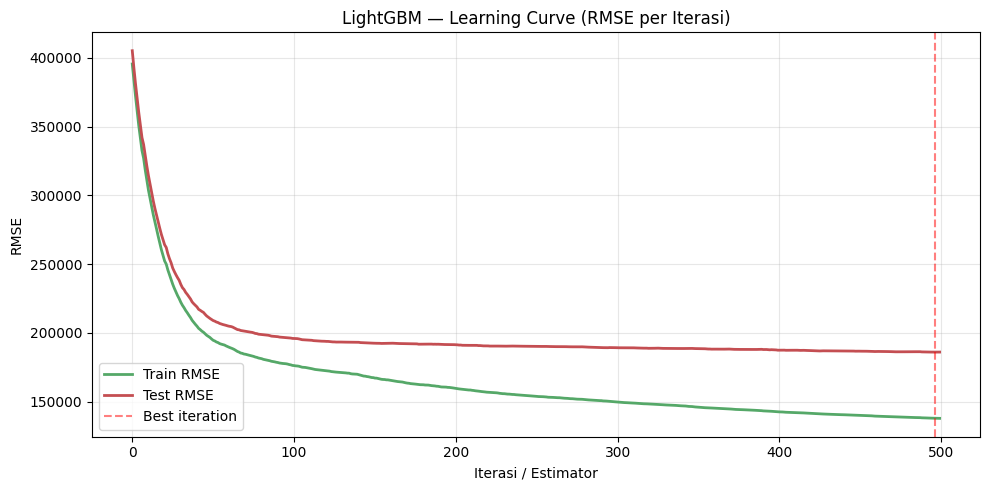

Learning curve LightGBM tersimpan


In [15]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_test  = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

params_lgb = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 63,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'verbose': -1,
    'random_state': 42
}

evals_result_lgb = {}
lgb_model = lgb.train(
    params_lgb,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=-1),
        lgb.record_evaluation(evals_result_lgb)
    ]
)

train_rmse_lgb = evals_result_lgb['train']['rmse']
test_rmse_lgb  = evals_result_lgb['test']['rmse']
best_iter_lgb  = lgb_model.best_iteration

print(f"Best iteration LightGBM: {best_iter_lgb}")
print(f"Best RMSE LightGBM (test): {min(test_rmse_lgb):,.0f}")

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(train_rmse_lgb, label='Train RMSE', color='#55A868', linewidth=2)
plt.plot(test_rmse_lgb,  label='Test RMSE',  color='#C44E52', linewidth=2)
plt.axvline(x=best_iter_lgb, color='red', linestyle='--', alpha=0.5, label='Best iteration')
plt.title('LightGBM — Learning Curve (RMSE per Iterasi)')
plt.xlabel('Iterasi / Estimator')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_learning_curve_lgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learning curve LightGBM tersimpan")

In [17]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lgb = lgb_model.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  EVALUASI MODEL: {model_name}")
    print(f"{'='*45}")
    print(f"  MAE  (Mean Absolute Error)    : ₹{mae:>12,.0f}")
    print(f"  MSE  (Mean Squared Error)     : ₹{mse:>12,.0f}")
    print(f"  RMSE (Root Mean Squared Error): ₹{rmse:>12,.0f}")
    print(f"  MAPE (Mean Abs Percentage Err): {mape:>11.2f}%")
    print(f"  R²   (R-squared Score)        : {r2:>12.4f}")
    print(f"{'='*45}")
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

metrics_xgb = evaluate_model(y_test, y_pred_xgb, "XGBoost")
metrics_lgb = evaluate_model(y_test, y_pred_lgb, "LightGBM")

# Tabel perbandingan
print("\nPERBANDINGAN PERFORMA")
comparison = pd.DataFrame({
    'Metrik': ['MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R²'],
    'XGBoost': [
        f"₹{metrics_xgb['MAE']:,.0f}",
        f"₹{metrics_xgb['MSE']:,.0f}",
        f"₹{metrics_xgb['RMSE']:,.0f}",
        f"{metrics_xgb['MAPE']:.2f}%",
        f"{metrics_xgb['R2']:.4f}"
    ],
    'LightGBM': [
        f"₹{metrics_lgb['MAE']:,.0f}",
        f"₹{metrics_lgb['MSE']:,.0f}",
        f"₹{metrics_lgb['RMSE']:,.0f}",
        f"{metrics_lgb['MAPE']:.2f}%",
        f"{metrics_lgb['R2']:.4f}"
    ]
})
print(comparison.to_string(index=False))

best_model_name = "LightGBM" if metrics_lgb['R2'] > metrics_xgb['R2'] else "XGBoost"
best_model = lgb_model if best_model_name == "LightGBM" else xgb_model
print(f"\nModel terbaik: {best_model_name}")


  EVALUASI MODEL: XGBoost
  MAE  (Mean Absolute Error)    : ₹     108,329
  MSE  (Mean Squared Error)     : ₹30,828,146,688
  RMSE (Root Mean Squared Error): ₹     175,579
  MAPE (Mean Abs Percentage Err):       30.10%
  R²   (R-squared Score)        :       0.8240

  EVALUASI MODEL: LightGBM
  MAE  (Mean Absolute Error)    : ₹     121,186
  MSE  (Mean Squared Error)     : ₹34,617,851,339
  RMSE (Root Mean Squared Error): ₹     186,059
  MAPE (Mean Abs Percentage Err):       32.92%
  R²   (R-squared Score)        :       0.8024

PERBANDINGAN PERFORMA
  Metrik         XGBoost        LightGBM
     MAE        ₹108,329        ₹121,186
     MSE ₹30,828,146,688 ₹34,617,851,339
    RMSE        ₹175,579        ₹186,059
MAPE (%)          30.10%          32.92%
      R²          0.8240          0.8024

Model terbaik: XGBoost


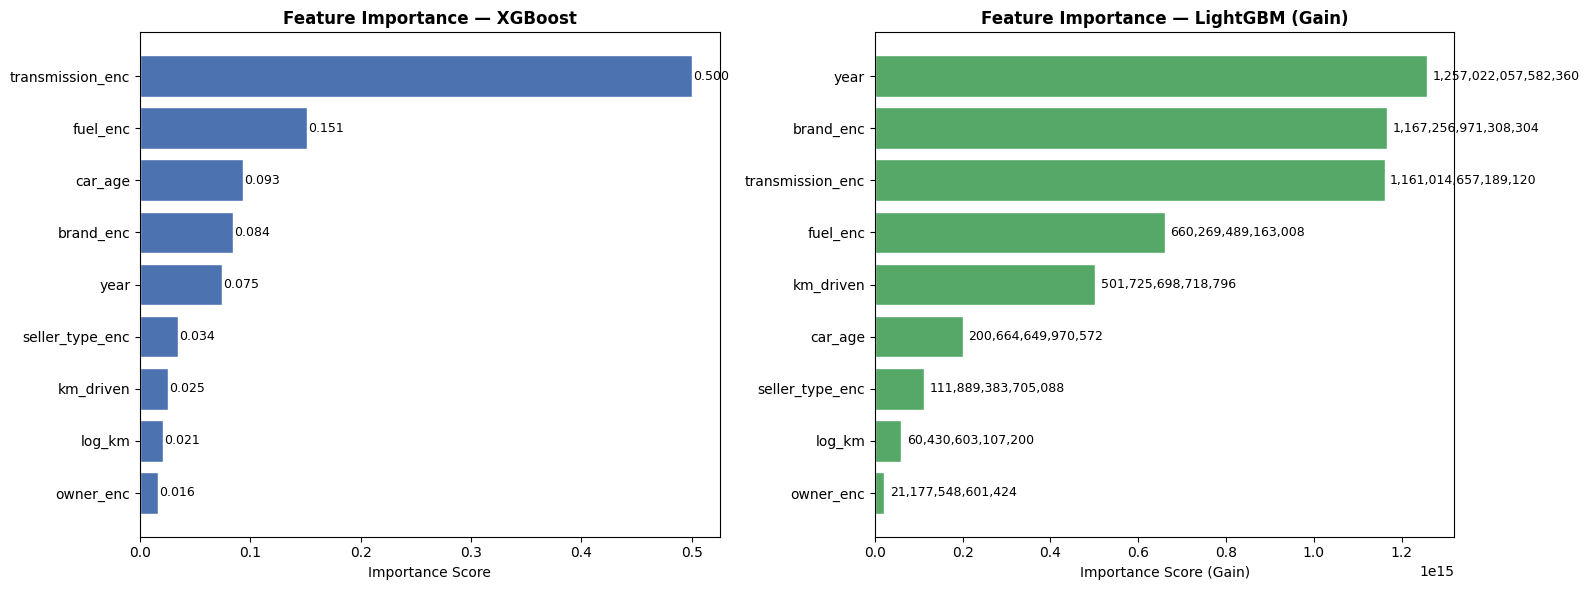

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost feature importance
xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values()

axes[0].barh(xgb_imp.index, xgb_imp.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, v in enumerate(xgb_imp.values):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# LightGBM feature importance
lgb_imp = pd.Series(
    lgb_model.feature_importance(importance_type='gain'),
    index=feature_cols
).sort_values()

axes[1].barh(lgb_imp.index, lgb_imp.values, color='#55A868', edgecolor='white')
axes[1].set_title('Feature Importance — LightGBM (Gain)', fontweight='bold')
axes[1].set_xlabel('Importance Score (Gain)')
for i, v in enumerate(lgb_imp.values):
    axes[1].text(
        v + lgb_imp.max() * 0.01, i,
        f'{v:,.0f}', va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
!pip install ipywidgets -q
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.5 MB/s eta 0:00:00


In [22]:
# Style & Layout
style  = {'description_width': '170px'}
layout = widgets.Layout(width='420px')
style_label = "font-family:'Segoe UI',Arial;font-size:13px;color:#555"

w_brand = widgets.Dropdown(
    options=sorted(data['brand'].unique().tolist()),
    value='Maruti',
    description='🚗 Brand Mobil:',
    style=style, layout=layout
)
w_year = widgets.IntSlider(
    value=2018, min=2000, max=2024, step=1,
    description='📅 Tahun Produksi:',
    style=style, layout=layout,
    continuous_update=False
)
w_km = widgets.IntSlider(
    value=50000, min=0, max=300000, step=1000,
    description='🛣️ KM Driven:',
    style=style, layout=layout,
    continuous_update=False
)
w_fuel = widgets.Dropdown(
    options=data['fuel'].unique().tolist(),
    value='Petrol',
    description='⛽ Bahan Bakar:',
    style=style, layout=layout
)
w_seller = widgets.Dropdown(
    options=data['seller_type'].unique().tolist(),
    value='Individual',
    description='🏪 Tipe Penjual:',
    style=style, layout=layout
)
w_trans = widgets.Dropdown(
    options=data['transmission'].unique().tolist(),
    value='Manual',
    description='⚙️ Transmisi:',
    style=style, layout=layout
)
w_owner = widgets.Dropdown(
    options=data['owner'].unique().tolist(),
    value='First Owner',
    description='👤 Kepemilikan:',
    style=style, layout=layout
)

btn_predict = widgets.Button(
    description='  🔍  Prediksi Harga Sekarang',
    button_style='',
    layout=widgets.Layout(width='260px', height='44px')
)
btn_predict.style.button_color = '#185FA5'
btn_predict.style.font_weight  = 'bold'

btn_reset = widgets.Button(
    description='↺ Reset',
    button_style='warning',
    layout=widgets.Layout(width='100px', height='44px')
)

output_area = widgets.Output()

In [28]:
def get_condition_label(km, year):
    age = 2024 - year
    if age <= 3 and km <= 30000:
        return "🟢 Kondisi Sangat Baik", "#d4edda", "#155724"
    elif age <= 6 and km <= 80000:
        return "🟡 Kondisi Baik", "#fff3cd", "#856404"
    elif age <= 10 and km <= 150000:
        return "🟠 Kondisi Cukup", "#ffe5d0", "#7d3c00"
    else:
        return "🔴 Kondisi Tua / Tinggi KM", "#f8d7da", "#721c24"

def get_mape_label(mape):
    if mape < 10:
        return "Sangat Akurat (MAPE < 10%)"
    elif mape < 20:
        return "Cukup Akurat (MAPE 10–20%)"
    else:
        return "Perlu Perhatian (MAPE > 20%)"

def on_predict_click(b):
    with output_area:
        clear_output()
        try:
            car_age = 2024 - w_year.value
            log_km  = np.log1p(w_km.value)

            row = {
                'year'            : w_year.value,
                'km_driven'       : w_km.value,
                'car_age'         : car_age,
                'log_km'          : log_km,
                'fuel_enc'        : le_dict['fuel'].transform([w_fuel.value])[0],
                'seller_type_enc' : le_dict['seller_type'].transform([w_seller.value])[0],
                'transmission_enc': le_dict['transmission'].transform([w_trans.value])[0],
                'owner_enc'       : le_dict['owner'].transform([w_owner.value])[0],
                'brand_enc'       : le_dict['brand'].transform([w_brand.value])[0],
            }
            X_new = pd.DataFrame([row])[feature_cols]

            pred_xgb  = xgb_model.predict(X_new)[0]
            pred_lgb  = lgb_model.predict(X_new)[0]
            best_pred = pred_lgb if best_model_name == "LightGBM" else pred_xgb
            selisih   = abs(pred_xgb - pred_lgb)
            konsensus = "✅ Konsensus tinggi" if selisih/best_pred < 0.1 else "⚠️ Prediksi berbeda signifikan"

            cond_label, cond_bg, cond_color = get_condition_label(w_km.value, w_year.value)
            mape_info = get_mape_label(metrics_lgb['MAPE'] if best_model_name == "LightGBM" else metrics_xgb['MAPE'])

            display(HTML(f"""
            <div style='font-family:"Segoe UI",Arial,sans-serif;max-width:500px;margin:12px 0'>

              <!-- Header -->
              <div style='background:linear-gradient(135deg,#185FA5,#0C447C);
                          border-radius:14px 14px 0 0;padding:18px 22px'>
                <h3 style='color:white;margin:0;font-size:17px;letter-spacing:0.3px'>
                  🎯 Hasil Prediksi Harga Mobil Bekas
                </h3>
                <p style='color:#B5D4F4;margin:4px 0 0;font-size:12px'>
                  Model terbaik: <b>{best_model_name}</b> &nbsp;|&nbsp; {mape_info}
                </p>
              </div>

              <!-- Harga utama -->
              <div style='background:#f0f7ff;border-left:4px solid #185FA5;
                          padding:18px 22px;border-right:1px solid #dce8f5'>
                <p style='margin:0;font-size:12px;color:#555;text-transform:uppercase;
                          letter-spacing:0.08em'>Estimasi Harga Terbaik</p>
                <p style='margin:4px 0 0;font-size:32px;font-weight:700;color:#0C447C'>
                  ₹ {best_pred:,.0f}
                </p>
                <p style='margin:2px 0 0;font-size:13px;color:#888'>
                  {best_pred/1e5:.2f} Lakh &nbsp;≈&nbsp;
                  Rp {best_pred*190:,.0f} <span style='font-size:10px'>(estimasi kurs ₹1≈Rp190)</span>
                </p>
              </div>

              <!-- Kondisi mobil -->
              <div style='background:{cond_bg};border-left:4px solid {cond_color};
                          padding:10px 22px;border-right:1px solid #dce8f5'>
                <p style='margin:0;font-size:13px;color:{cond_color};font-weight:600'>
                  {cond_label} &nbsp;|&nbsp; Usia: {car_age} tahun &nbsp;|&nbsp; KM: {w_km.value:,}
                </p>
              </div>

              <!-- Perbandingan model -->
              <div style='background:white;border:1px solid #dce8f5;
                          border-top:none;padding:16px 22px'>
                <p style='margin:0 0 10px;font-size:12px;color:#888;
                          text-transform:uppercase;letter-spacing:0.08em'>
                  Perbandingan Kedua Model
                </p>
                <table style='width:100%;font-size:13px;border-collapse:collapse'>
                  <tr style='background:#f8f9fa'>
                    <th style='padding:8px 10px;text-align:left;
                               border-radius:6px 0 0 0;color:#444'>Model</th>
                    <th style='padding:8px 10px;text-align:right;color:#444'>
                      Prediksi (₹)</th>
                    <th style='padding:8px 10px;text-align:right;
                               border-radius:0 6px 0 0;color:#444'>Lakh</th>
                  </tr>
                  <tr style='border-bottom:1px solid #eee'>
                    <td style='padding:9px 10px;color:#185FA5;font-weight:600'>
                      {"🏆 " if best_model_name=="XGBoost" else ""}XGBoost</td>
                    <td style='padding:9px 10px;text-align:right'>
                      ₹ {pred_xgb:,.0f}</td>
                    <td style='padding:9px 10px;text-align:right;color:#888'>
                      {pred_xgb/1e5:.2f}</td>
                  </tr>
                  <tr>
                    <td style='padding:9px 10px;color:#3B6D11;font-weight:600'>
                      {"🏆 " if best_model_name=="LightGBM" else ""}LightGBM</td>
                    <td style='padding:9px 10px;text-align:right'>
                      ₹ {pred_lgb:,.0f}</td>
                    <td style='padding:9px 10px;text-align:right;color:#888'>
                      {pred_lgb/1e5:.2f}</td>
                  </tr>
                </table>
                <p style='margin:10px 0 0;font-size:12px;color:#666'>
                  Selisih antar model: ₹ {selisih:,.0f} &nbsp;|&nbsp; {konsensus}
                </p>
              </div>

              <!-- Input summary -->
              <div style='background:#fafafa;border:1px solid #dce8f5;
                          border-top:none;border-radius:0 0 14px 14px;
                          padding:14px 22px'>
                <p style='margin:0 0 8px;font-size:12px;color:#888;
                          text-transform:uppercase;letter-spacing:0.08em'>
                  Ringkasan Input
                </p>
                <div style='display:flex;flex-wrap:wrap;gap:6px'>
                  {''.join([
                    f"<span style='background:#E6F1FB;color:#0C447C;border-radius:99px;"
                    f"padding:3px 12px;font-size:12px'>{t}</span>"
                    for t in [
                        w_brand.value, str(w_year.value),
                        f"{w_km.value:,} km", w_fuel.value,
                        w_trans.value, w_owner.value, w_seller.value
                    ]
                  ])}
                </div>
                <p style='font-size:10px;color:#aaa;margin:10px 0 0'>
                  * Prediksi bersifat estimasi. Harga aktual dipengaruhi kondisi fisik,
                    lokasi, dan negosiasi pasar.
                </p>
              </div>
            </div>
            """))

        except Exception as e:
            display(HTML(f"""
            <div style='background:#f8d7da;border-left:4px solid #dc3545;
                        border-radius:8px;padding:14px 18px;font-family:Arial;
                        max-width:500px'>
              <b style='color:#721c24'>❌ Error:</b>
              <p style='color:#721c24;margin:4px 0 0'>{str(e)}</p>
              <p style='color:#888;font-size:12px;margin:8px 0 0'>
                Coba pilih brand lain yang umum seperti Maruti, Hyundai, atau Honda.
              </p>
            </div>
            """))

def on_reset_click(b):
    with output_area:
        clear_output()
    w_brand.value  = 'Maruti'
    w_year.value   = 2018
    w_km.value     = 50000
    w_fuel.value   = 'Petrol'
    w_seller.value = 'Individual'
    w_trans.value  = 'Manual'
    w_owner.value  = 'First Owner'

btn_predict.on_click(on_predict_click)
btn_reset.on_click(on_reset_click)

# ── Tampilkan UI ──
display(HTML("""
<div style='font-family:"Segoe UI",Arial;max-width:500px;
            background:white;border-radius:14px;
            border:1px solid #dce8f5;overflow:hidden;margin-bottom:4px'>
  <div style='background:linear-gradient(135deg,#185FA5,#0C447C);
              padding:18px 22px'>
    <h2 style='color:white;margin:0;font-size:18px'>🚗 Car Price Predictor</h2>
    <p style='color:#B5D4F4;margin:4px 0 0;font-size:12px'>
      XGBoost &amp; LightGBM · Dataset Car Dekho India
    </p>
  </div>
  <div style='padding:4px 0 8px;background:#f8fafd;
              border-bottom:1px solid #dce8f5'>
    <p style='margin:10px 22px 2px;font-size:12px;color:#888;
              text-transform:uppercase;letter-spacing:0.08em'>
      Parameter Mobil
    </p>
  </div>
</div>
"""))

display(w_brand, w_year, w_km, w_fuel, w_seller, w_trans, w_owner)

display(HTML("<div style='height:10px'></div>"))
display(widgets.HBox([btn_predict, btn_reset],
        layout=widgets.Layout(gap='10px')))
display(HTML("<div style='height:6px'></div>"))
display(output_area)

Dropdown(description='🚗 Brand Mobil:', index=18, layout=Layout(width='420px'), options=('Ambassador', 'Audi', …

IntSlider(value=2018, continuous_update=False, description='📅 Tahun Produksi:', layout=Layout(width='420px'), …

IntSlider(value=50000, continuous_update=False, description='🛣️ KM Driven:', layout=Layout(width='420px'), max…

Dropdown(description='⛽ Bahan Bakar:', layout=Layout(width='420px'), options=('Petrol', 'Diesel', 'CNG', 'LPG'…

Dropdown(description='🏪 Tipe Penjual:', layout=Layout(width='420px'), options=('Individual', 'Dealer', 'Trustm…

Dropdown(description='⚙️ Transmisi:', layout=Layout(width='420px'), options=('Manual', 'Automatic'), style=Des…

Dropdown(description='👤 Kepemilikan:', layout=Layout(width='420px'), options=('First Owner', 'Second Owner', '…

Output()